# E-commerce Product Ratings Analysis

## Introduction

### This project explores customer rating patterns in an e-commerce dataset. The aim is to investigate whether product category, price, and review count are associated with higher product ratings. By using data cleaning, descriptive statistics, and visualisation, the project identifies useful patterns in customer evaluations across different types of products.

## Research Questions
### 1.How does Abbott Laboratories (ABT) compare with the sample average in terms of sales over time?
### 2.How does ABT compare with the sample average in terms of net income over time?
### 3.How does ABT’s profitability compare with the sample average across fiscal years?
### 4.What is the relationship between firm size and profitability, and how does ABT compare with other firms in the sample?

In [5]:
import os
print(os.getcwd())
print(os.listdir())

/
['home', 'usr', '.resolve', 'bin', 'sbin', '.file', 'etc', 'var', 'Library', 'System', '.VolumeIcon.icns', 'private', '.vol', 'Users', 'Applications', 'opt', 'dev', 'Volumes', '.nofollow', 'tmp', 'cores']


In [2]:
import pandas as pd

df = pd.read_excel("/Users/zhoujinnan/Desktop/ACC102_Mini_Assignment/wrds_data.xlsx")
df.head()

,costat,curcd,datafmt,indfmt,consol,tic,datadate,gvkey,conm,sic,fyear,at,ni,sale,firm_size,profitability
0,A,USD,STD,INDL,C,AIR,2018-05-31,1004,AAR CORP,5080,2017,1524.7,15.6,1748.3,7.329553,0.010232
1,A,USD,STD,INDL,C,AIR,2019-05-31,1004,AAR CORP,5080,2018,1517.2,7.5,2051.8,7.324622,0.004943
2,A,USD,STD,INDL,C,AIR,2020-05-31,1004,AAR CORP,5080,2019,2079.0,4.4,2089.3,7.639642,0.002116
3,A,USD,STD,INDL,C,AIR,2021-05-31,1004,AAR CORP,5080,2020,1539.7,35.8,1651.4,7.339343,0.023251
4,A,USD,STD,INDL,C,AIR,2022-05-31,1004,AAR CORP,5080,2021,1573.9,78.7,1817.1,7.361312,0.050003


In [4]:
df.head(10)

,costat,curcd,datafmt,indfmt,consol,tic,datadate,gvkey,conm,sic,fyear,at,ni,sale,firm_size,profitability
0,A,USD,STD,INDL,C,AIR,2018-05-31,1004,AAR CORP,5080,2017,1524.7,15.6,1748.3,7.329553,0.010232
1,A,USD,STD,INDL,C,AIR,2019-05-31,1004,AAR CORP,5080,2018,1517.2,7.5,2051.8,7.324622,0.004943
2,A,USD,STD,INDL,C,AIR,2020-05-31,1004,AAR CORP,5080,2019,2079.0,4.4,2089.3,7.639642,0.002116
3,A,USD,STD,INDL,C,AIR,2021-05-31,1004,AAR CORP,5080,2020,1539.7,35.8,1651.4,7.339343,0.023251
4,A,USD,STD,INDL,C,AIR,2022-05-31,1004,AAR CORP,5080,2021,1573.9,78.7,1817.1,7.361312,0.050003
5,A,USD,STD,INDL,C,AIR,2023-05-31,1004,AAR CORP,5080,2022,1833.1,90.2,1990.6,7.513764,0.049206
6,A,USD,STD,INDL,C,AAL,2018-12-31,1045,AMERICAN AIRLINES GROUP INC,4512,2018,60580.0,1412.0,44541.0,11.011720,0.023308
7,A,USD,STD,INDL,C,AAL,2019-12-31,1045,AMERICAN AIRLINES GROUP INC,4512,2019,59995.0,1686.0,45768.0,11.002017,0.028102
8,A,USD,STD,INDL,C,AAL,2020-12-31,1045,AMERICAN AIRLINES GROUP INC,4512,2020,62008.0,-8885.0,17337.0,11.035019,-0.143288
9,A,USD,STD,INDL,C,AAL,2021-12-31,1045,AMERICAN AIRLINES GROUP INC,4512,2021,66467.0,-1993.0,29882.0,11.104461,-0.029985


In [5]:
print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df.isnull().sum().sort_values(ascending=False))
print(df.describe())

(49434, 16)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49434 entries, 0 to 49433
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   costat         49434 non-null  object        
 1   curcd          49434 non-null  object        
 2   datafmt        49434 non-null  object        
 3   indfmt         49434 non-null  object        
 4   consol         49434 non-null  object        
 5   tic            49430 non-null  object        
 6   datadate       49434 non-null  datetime64[ns]
 7   gvkey          49434 non-null  int64         
 8   conm           49434 non-null  object        
 9   sic            49434 non-null  int64         
 10  fyear          49434 non-null  int64         
 11  at             33901 non-null  float64       
 12  ni     

In [18]:
clean_df = df.dropna(subset=["at", "ni", "sale", "firm_size", "profitability"])
print(clean_df.shape)

(33709, 16)


In [19]:
clean_df[["at", "ni", "sale", "firm_size", "profitability"]].describe()

,at,ni,sale,firm_size,profitability
count,3.370900e+04,33709.000000,33709.000000,33709.000000,33709.000000
mean,2.113723e+04,428.524804,5321.653883,6.390779,-2.181998
std,1.471469e+05,2661.562273,22853.707704,3.130479,132.006957
min,1.000000e-03,-22819.000000,-24954.684000,-6.907755,-15612.600000
25%,8.079400e+01,-16.114000,19.484000,4.391903,-0.171231
50%,8.439930e+02,4.145000,280.338000,6.738144,0.008334
75%,5.164915e+03,147.500000,2122.000000,8.549644,0.049494
max,4.325437e+06,99803.000000,608481.000000,15.280024,13583.000000


In [20]:
clean_df.groupby("fyear")[["sale", "ni", "firm_size", "profitability"]].mean()

,sale,ni,firm_size,profitability
fyear,,,,
2017,9271.621541,581.020713,6.052888,-2.218623
2018,5531.979269,441.466721,6.387509,-1.684633
2019,5444.683143,416.736555,6.400993,-2.644693
2020,4764.152610,230.197773,6.386154,-2.443870
2021,5188.369136,537.483266,6.498372,-4.138706
2022,5476.047732,461.010208,6.358930,-1.104654
2023,5262.348232,459.794252,6.337474,-1.102618


In [21]:
clean_df[["at", "ni", "sale", "firm_size", "profitability"]].corr()

,at,ni,sale,firm_size,profitability
at,1.000000,0.408464,0.381259,0.290179,0.002397
ni,0.408464,1.000000,0.633944,0.277459,0.003173
sale,0.381259,0.633944,1.000000,0.357298,0.003941
firm_size,0.290179,0.277459,0.357298,1.000000,0.058180
profitability,0.002397,0.003173,0.003941,0.058180,1.000000


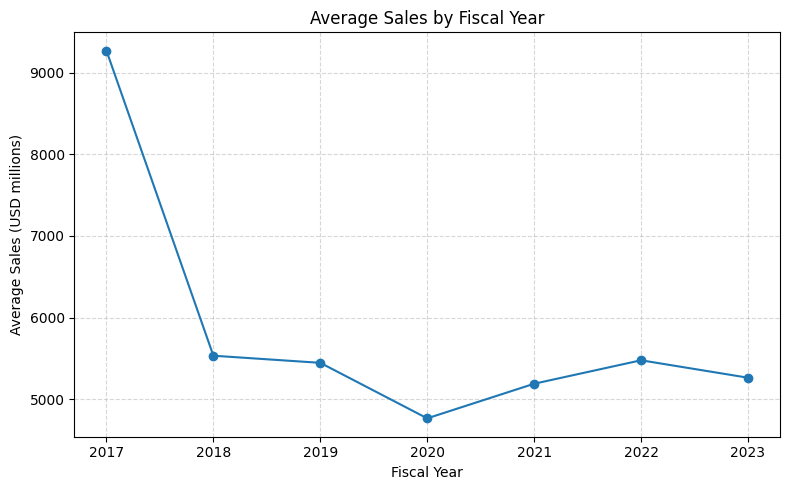

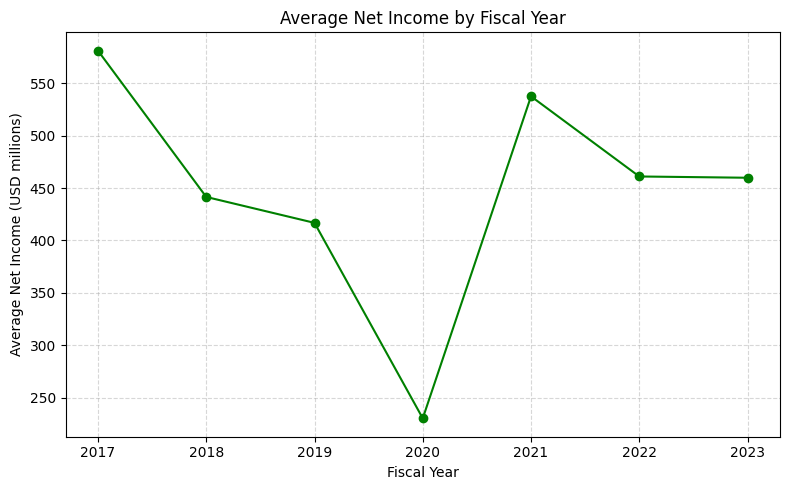

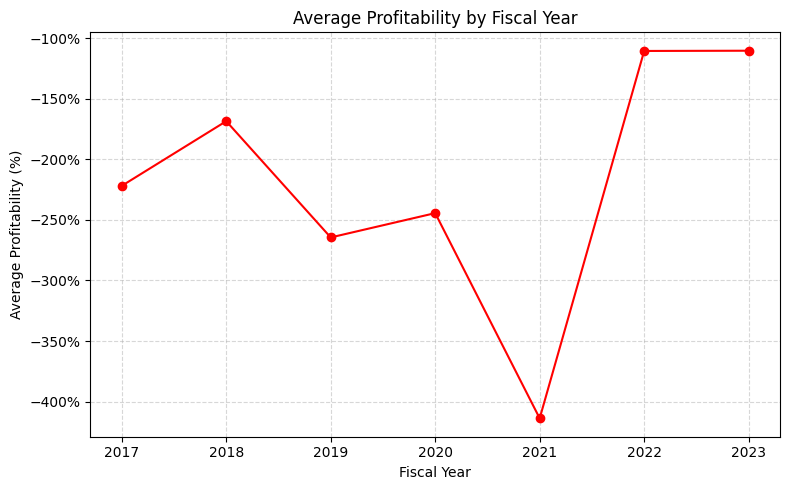

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Average Sales by Fiscal Year
plt.figure(figsize=(8,5))
clean_df.groupby("fyear")["sale"].mean().plot(marker="o")
plt.title("Average Sales by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Sales (USD millions)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Average Net Income by Fiscal Year
plt.figure(figsize=(8,5))
clean_df.groupby("fyear")["ni"].mean().plot(marker="o", color="green")
plt.title("Average Net Income by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Net Income (USD millions)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Average Profitability by Fiscal Year
plt.figure(figsize=(8,5))
ax = clean_df.groupby("fyear")["profitability"].mean().plot(marker="o", color="red")
plt.title("Average Profitability by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

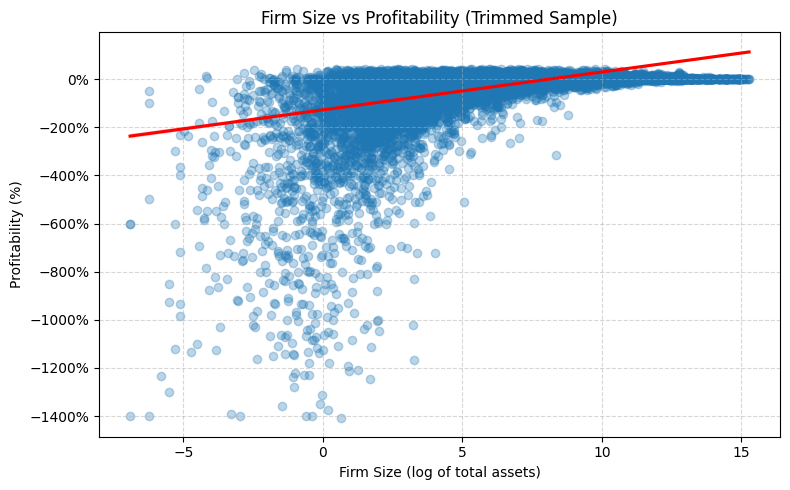

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

lower = clean_df["profitability"].quantile(0.01)
upper = clean_df["profitability"].quantile(0.99)

trimmed_df = clean_df[
    (clean_df["profitability"] >= lower) & 
    (clean_df["profitability"] <= upper)
]

plt.figure(figsize=(8,5))
ax = plt.gca()

sns.regplot(
    data=trimmed_df,
    x="firm_size",
    y="profitability",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Firm Size vs Profitability (Trimmed Sample)")
plt.xlabel("Firm Size (log of total assets)")
plt.ylabel("Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure and Table Titles

Figure 1. Average Sales by Year

Figure 2. Average Net Income by Year

Figure 3. Average Profitability by Year

Figure 4. Firm Size vs Profitability (Trimmed)

## Analysis of Firm Size and Profitability from 2017 to 2023
## 1. Introduction
This report analyses firm-level financial data from 2017 to 2023. The main aim is to examine the relationship between firm size and profitability. The report also considers how sales, net income, and profitability changed over time.
The original dataset contains 49,434 observations and 16 variables. After removing missing values in the key variables, the final sample includes 33,709 observations.

## 2. Descriptive Statistics
The descriptive statistics show that the financial variables are highly skewed. For example, the mean values of total assets, net income, and sales are much larger than their median values. This suggests that a small number of very large firms have a strong effect on the average.
By contrast, firm size is relatively more stable. Profitability has a mean of -2.18 and a median close to zero, which suggests that this variable is affected by extreme values. Therefore, profitability should be interpreted with caution.
[Insert Table 1: Descriptive Statistics]

## 3. Analysis by Year
The yearly analysis shows that average sales were highest in 2017 and then declined in later years. Net income also changed over time, with a clear drop in 2020 followed by a recovery. This suggests that firms in the sample experienced weaker performance in 2020.
Average firm size remained relatively stable throughout the period, while average profitability was negative in all years and fluctuated considerably. However, the profitability results may be influenced by outliers.
[Insert Figure 1: Average Sales by Year]
[Insert Figure 2: Average Net Income by Year]
[Insert Figure 3: Average Profitability by Year]

## 4. Correlation and Scatter Plot Analysis
The correlation between firm size and profitability is 0.058, which indicates a very weak positive relationship. This suggests that larger firms are not necessarily more profitable.
Other variables show stronger relationships. For example, sales and net income are positively correlated, which is expected because firms with higher sales often generate higher profits.
To examine the relationship further, a scatter plot of firm size and profitability was created after trimming the most extreme profitability values. The points are widely dispersed and do not show a clear pattern. This supports the correlation result that the relationship between firm size and profitability is weak.
[Insert Table 2: Correlation Matrix]
[Insert Figure 4: Firm Size vs Profitability (Trimmed)]


## 5. Conclusion
This report examined firm-level financial data from 2017 to 2023. The results show that the data are highly skewed, especially for total assets, sales, and net income. Sales and net income changed over time, while firm size remained relatively stable.
Most importantly, the relationship between firm size and profitability is very weak. Both the correlation analysis and the scatter plot suggest that larger firms are not necessarily more profitable in this sample.

## Figure and Table Titles
Table 1. Descriptive Statistics

Table 2. Correlation Matrix

Figure 1. Average Sales by Year

Figure 2. Average Net Income by Year

Figure 3. Average Profitability by Year

Figure 4. Firm Size vs Profitability (Trimmed)


In [26]:
print(clean_df.columns)

if "tic" in clean_df.columns:
    print(clean_df[clean_df["tic"] == "ABT"].shape)
    print(clean_df[clean_df["tic"] == "ABT"].head())

elif "conm" in clean_df.columns:
    print(clean_df[clean_df["conm"].str.contains("Abbott", case=False, na=False)].shape)
    print(clean_df[clean_df["conm"].str.contains("Abbott", case=False, na=False)].head())

else:
    print("No tic or conm column found in clean_df.")

Index(['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate',
       'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size',
       'profitability'],
      dtype='object')
(6, 16)
   costat curcd datafmt indfmt consol  tic   datadate  gvkey  \
36      A   USD     STD   INDL      C  ABT 2018-12-31   1078   
37      A   USD     STD   INDL      C  ABT 2019-12-31   1078   
38      A   USD     STD   INDL      C  ABT 2020-12-31   1078   
39      A   USD     STD   INDL      C  ABT 2021-12-31   1078   
40      A   USD     STD   INDL      C  ABT 2022-12-31   1078   

                   conm   sic  fyear       at      ni     sale  firm_size  \
36  ABBOTT LABORATORIES  3845   2018  67173.0  2368.0  30578.0  11.115027   
37  ABBOTT LABORATORIES  3845   2019  67887.0  3687.0  31904.0  11.125600   
38  ABBOTT LABORATORIES  3845   2020  72548.0  4495.0  34608.0  11.192004   
39  ABBOTT LABORATORIES  3845   2021  75196.0  7071.0  43075.0  11.227853   
40  ABBOTT LABORATORIES  3

In [27]:
abt_df = clean_df[clean_df["tic"] == "ABT"].copy()

In [28]:
abt_df = clean_df[clean_df["tic"] == "ABT"].copy()
abt_df = abt_df.sort_values("fyear")

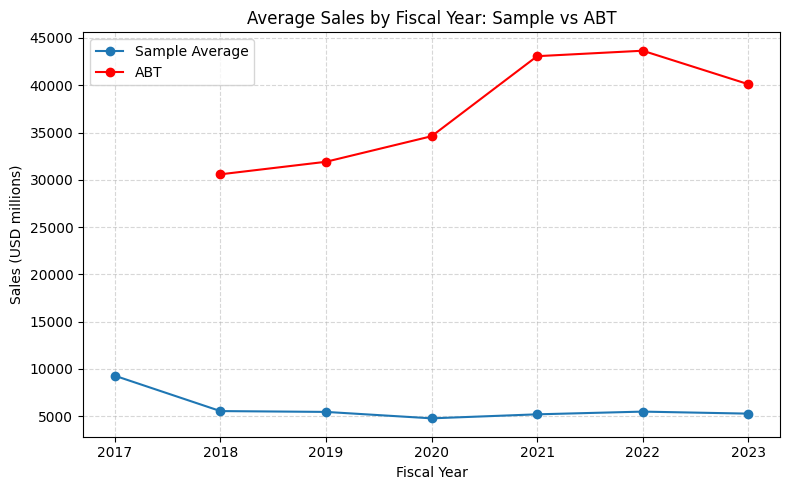

In [39]:
import matplotlib.pyplot as plt

abt_df = clean_df[clean_df["tic"] == "ABT"].copy()
abt_df = abt_df.sort_values("fyear")

sample_sales = clean_df.groupby("fyear")["sale"].mean()
abt_sales = abt_df.groupby("fyear")["sale"].mean()

plt.figure(figsize=(8,5))
plt.plot(sample_sales.index, sample_sales.values, marker="o", label="Sample Average")
plt.plot(abt_sales.index, abt_sales.values, marker="o", color="red", label="ABT")
plt.title("Average Sales by Fiscal Year: Sample vs ABT")
plt.xlabel("Fiscal Year")
plt.ylabel("Sales (USD millions)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
common_years = sorted(abt_df["fyear"].unique())

sample_sales = clean_df[clean_df["fyear"].isin(common_years)].groupby("fyear")["sale"].mean()
abt_sales = abt_df.groupby("fyear")["sale"].mean()

## Figure 1. Average Sales by Fiscal Year: Sample vs ABT
### Caption
#### This figure compares the average annual sales of firms in the sample with the annual sales of Abbott Laboratories (ABT) from 2017 to 2023.
### Analysis
#### Figure 1 shows that ABT’s sales were consistently far above the sample average throughout the period. While the sample average dropped sharply from 2017 to 2018 and then remained relatively stable at around USD 5,000–5,500 million, ABT’s sales followed a clear upward trend from 2018 to 2022 before declining slightly in 2023. In particular, ABT experienced a strong increase between 2020 and 2021, after which sales stayed at a high level. Overall, the figure suggests that ABT is substantially larger than the average firm in the sample in terms of revenue generation.

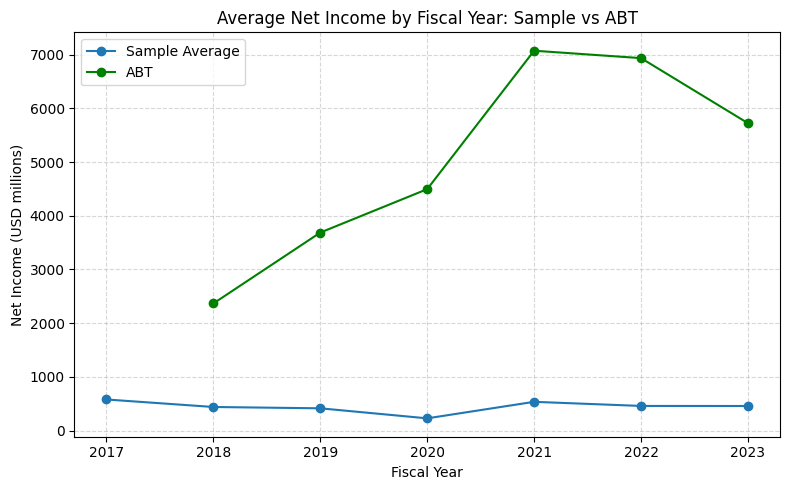

In [30]:
sample_ni = clean_df.groupby("fyear")["ni"].mean()
abt_ni = abt_df.groupby("fyear")["ni"].mean()

plt.figure(figsize=(8,5))
plt.plot(sample_ni.index, sample_ni.values, marker="o", label="Sample Average")
plt.plot(abt_ni.index, abt_ni.values, marker="o", color="green", label="ABT")
plt.title("Average Net Income by Fiscal Year: Sample vs ABT")
plt.xlabel("Fiscal Year")
plt.ylabel("Net Income (USD millions)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 2. Average Net Income by Fiscal Year: Sample vs ABT
### Caption
#### This figure compares the average annual net income of firms in the sample with the annual net income of Abbott Laboratories (ABT) from 2017 to 2023.
### Analysis
#### Figure 2 shows that ABT’s net income was consistently much higher than the sample average over the observed period. While the sample average remained relatively low and fairly stable, ABT’s net income increased strongly from 2018 to 2021, rising from around USD 2,400 million to over USD 7,000 million. After peaking in 2021, ABT’s net income declined slightly in 2022 and more noticeably in 2023, but it still remained far above the sample average. This pattern suggests that ABT achieved substantially stronger earnings performance than the typical firm in the sample, despite some moderation in the most recent year.

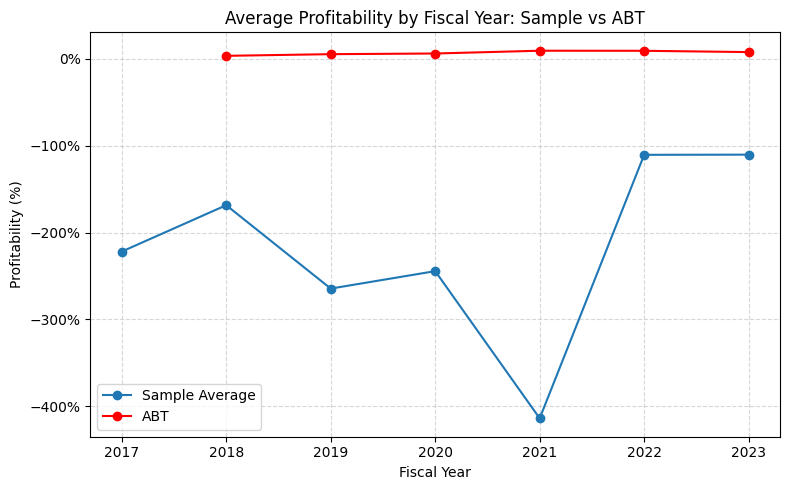

In [31]:
import matplotlib.ticker as mtick

sample_profit = clean_df.groupby("fyear")["profitability"].mean()
abt_profit = abt_df.groupby("fyear")["profitability"].mean()

plt.figure(figsize=(8,5))
ax = plt.gca()

plt.plot(sample_profit.index, sample_profit.values, marker="o", label="Sample Average")
plt.plot(abt_profit.index, abt_profit.values, marker="o", color="red", label="ABT")
plt.title("Average Profitability by Fiscal Year: Sample vs ABT")
plt.xlabel("Fiscal Year")
plt.ylabel("Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 3. Average Profitability by Fiscal Year: Sample vs ABT
### Caption
#### This figure compares the average annual profitability of firms in the sample with the annual profitability of Abbott Laboratories (ABT) from 2017 to 2023. Profitability is measured as net income divided by total assets.
### Analysis
#### Figure 3 shows a striking contrast between ABT and the sample average in terms of profitability. ABT maintained positive and relatively stable profitability throughout the period, generally remaining within a narrow range above zero. By contrast, the sample average is strongly negative in every year and highly volatile, with the lowest point occurring in 2021. This pattern suggests that the sample mean is likely influenced by extreme negative observations or outliers, which pull the average downward. Therefore, while the figure clearly shows that ABT performed much better than the sample average, the unusually large negative sample values should be interpreted with caution.

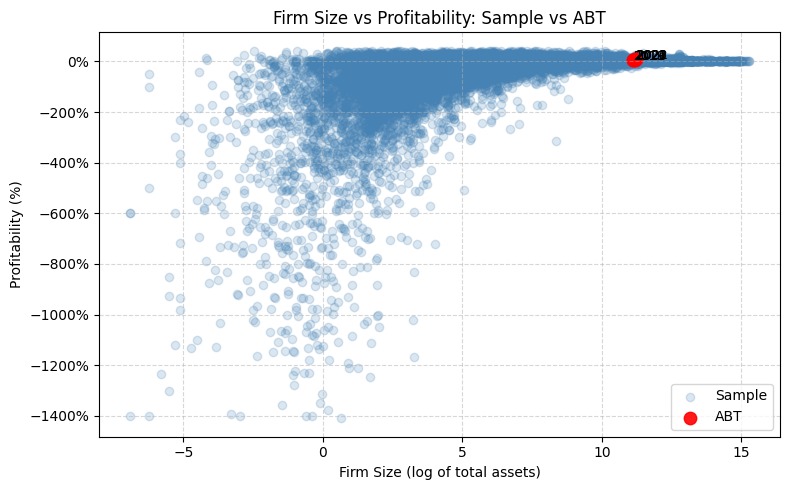

In [33]:
plt.figure(figsize=(8,5))
ax = plt.gca()

plt.scatter(trimmed_df["firm_size"], trimmed_df["profitability"],
            alpha=0.2, color="steelblue", label="Sample")
plt.scatter(abt_trimmed["firm_size"], abt_trimmed["profitability"],
            alpha=0.9, color="red", s=80, label="ABT")

for _, row in abt_trimmed.iterrows():
    plt.text(row["firm_size"], row["profitability"], str(row["fyear"]), fontsize=9)

plt.title("Firm Size vs Profitability: Sample vs ABT")
plt.xlabel("Firm Size (log of total assets)")
plt.ylabel("Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 4. Firm Size vs Profitability: Sample vs ABT
### Caption
#### This figure plots the relationship between firm size and profitability for the full sample, with Abbott Laboratories (ABT) highlighted in red. Firm size is measured as the natural logarithm of total assets, and profitability is measured as net income divided by total assets.
### Analysis
#### Figure 4 shows substantial dispersion in profitability across the sample, especially among smaller firms. Many firms report negative profitability, and extreme negative values are concentrated among firms with relatively small or moderate asset size. In contrast, ABT is located on the far right of the figure, indicating that it is one of the largest firms in the sample. Its profitability remains positive and relatively stable across years, placing it above a large proportion of the sample observations. The figure therefore suggests that ABT combines large firm size with solid financial performance, while smaller firms in the sample tend to display much greater volatility and more frequent losses.

## Overall Discussion
#### Taken together, the four figures indicate that Abbott Laboratories (ABT) outperforms the sample average on several key dimensions. ABT reports substantially higher sales and net income than the average firm and maintains positive profitability over time. In contrast, the sample average profitability is strongly negative and appears to be heavily affected by extreme observations. The firm size–profitability scatter plot further shows that ABT is one of the largest firms in the sample and achieves relatively stable positive returns. Overall, the evidence suggests that ABT is a large and financially strong firm compared with the broader sample.

In [44]:
 import pandas as pd

# 复制一份，避免改原数据
data = df.copy()

# 去掉 ticker 可能存在的空格，并统一大写
data['tic'] = data['tic'].astype(str).str.strip().str.upper()

# SIC 转成字符串，方便判断前两位
data['sic'] = data['sic'].astype(str).str.strip()

# fiscal year 转成数值
data['fyear'] = pd.to_numeric(data['fyear'], errors='coerce')

In [45]:
abt_info = data[data['tic'] == 'ABT'][['tic', 'conm', 'sic']].drop_duplicates()
print("ABT information:")
print(abt_info)

ABT information:
    tic                 conm   sic
36  ABT  ABBOTT LABORATORIES  3845


In [46]:
abt_sic = data.loc[data['tic'] == 'ABT', 'sic'].dropna().iloc[0]
print("ABT SIC:", abt_sic)

ABT SIC: 3845


In [47]:
same_sic = data[data['sic'] == abt_sic]

same_sic_companies = same_sic[['tic', 'conm', 'sic']].drop_duplicates().sort_values(by='tic')

print("Companies with the same SIC as ABT:")
print(same_sic_companies)
print("Number of unique companies with same SIC:", same_sic_companies['tic'].nunique())

Companies with the same SIC as ABT:
         tic                          conm   sic
36       ABT           ABBOTT LABORATORIES  3845
10205   ADMT  ADM TRONICS UNLIMITED INC/DE  3845
34946  ALRTF       ALR TECHNOLOGIES SG LTD  3845
5185    APYX             APYX MEDICAL CORP  3845
42317   ARAY                   ACCURAY INC  3845
...      ...                           ...   ...
11373  VRAYQ                   VIEWRAY INC  3845
19987   VTAK        CATHETER PRECISION INC  3845
19503   XAIR                BEYOND AIR INC  3845
14250  ZOMDF                 ZOMEDICA CORP  3845
35803  ZYXIQ                     ZYNEX INC  3845

[105 rows x 3 columns]
Number of unique companies with same SIC: 105


In [48]:
abt_sic_prefix2 = abt_sic[:2]   # 例如 '38'

broad_industry = data[data['sic'].str.startswith(abt_sic_prefix2, na=False)]

broad_industry_companies = broad_industry[['tic', 'conm', 'sic']].drop_duplicates().sort_values(by=['sic', 'tic'])

print(f"Companies with SIC starting with {abt_sic_prefix2}:")
print(broad_industry_companies)
print("Number of unique companies in broad industry:", broad_industry_companies['tic'].nunique())

Companies with SIC starting with 38:
        tic                          conm   sic
12506  ACFN              ACORN ENERGY INC  3812
28006  ARBE             ARBE ROBOTICS LTD  3812
45007  CODA        CODA OCTOPUS GROUP INC  3812
26118   DRS              LEONARDO DRS INC  3812
33063  ESLT             ELBIT SYSTEMS LTD  3812
...     ...                           ...   ...
1393   KODK              EASTMAN KODAK CO  3861
23183  MITQ  MOVING IMAGE TECHNOLOGIS INC  3861
30244  YIBO  PLANET IMAGE INTERNATION LTD  3861
15103  FOSL              FOSSIL GROUP INC  3873
3043    MOV              MOVADO GROUP INC  3873

[345 rows x 3 columns]
Number of unique companies in broad industry: 345


In [49]:
same_sic_years = same_sic.groupby('fyear')['tic'].nunique().reset_index(name='num_companies')
print("Same SIC: number of companies by year")
print(same_sic_years)

Same SIC: number of companies by year
   fyear  num_companies
0   2017              5
1   2018             77
2   2019             85
3   2020             92
4   2021             93
5   2022             97
6   2023             91


In [50]:
broad_industry_years = broad_industry.groupby('fyear')['tic'].nunique().reset_index(name='num_companies')
print("Broad industry: number of companies by year")
print(broad_industry_years)

Broad industry: number of companies by year
   fyear  num_companies
0   2017             25
1   2018            241
2   2019            274
3   2020            292
4   2021            301
5   2022            322
6   2023            297


In [51]:
abt_df = same_sic[same_sic['tic'] == 'ABT']
peer_df = same_sic[same_sic['tic'] != 'ABT']

print("ABT rows:", len(abt_df))
print("Peer rows (same SIC, excluding ABT):", len(peer_df))
print("Number of peer companies:", peer_df['tic'].nunique())

ABT rows: 6
Peer rows (same SIC, excluding ABT): 534
Number of peer companies: 104


In [52]:
abt_df_broad = broad_industry[broad_industry['tic'] == 'ABT']
peer_df_broad = broad_industry[broad_industry['tic'] != 'ABT']

print("ABT rows in broad industry:", len(abt_df_broad))
print("Peer rows in broad industry (excluding ABT):", len(peer_df_broad))
print("Number of peer companies in broad industry:", peer_df_broad['tic'].nunique())

ABT rows in broad industry: 6
Peer rows in broad industry (excluding ABT): 1746
Number of peer companies in broad industry: 344


In [53]:
print("========== SUMMARY ==========")
print(f"ABT SIC: {abt_sic}")
print(f"Same SIC unique companies: {same_sic_companies['tic'].nunique()}")
print(f"Same SIC peer companies excluding ABT: {peer_df['tic'].nunique()}")
print(f"Broad industry ({abt_sic_prefix2}xx) unique companies: {broad_industry_companies['tic'].nunique()}")
print(f"Broad industry peer companies excluding ABT: {peer_df_broad['tic'].nunique()}")

========== SUMMARY ==========
ABT SIC: 3845
Same SIC unique companies: 105
Same SIC peer companies excluding ABT: 104
Broad industry (38xx) unique companies: 345
Broad industry peer companies excluding ABT: 344


In [54]:
print(same_sic_companies.to_string(index=False))

  tic                         conm  sic
  ABT          ABBOTT LABORATORIES 3845
 ADMT ADM TRONICS UNLIMITED INC/DE 3845
ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APYX            APYX MEDICAL CORP 3845
 ARAY                  ACCURAY INC 3845
 BDMD BAIRD MEDICAL INVST HLDS LTD 3845
 BEAT                HEARTBEAM INC 3845
 BFLY        BUTTERFLY NETWORK INC 3845
  BSX       BOSTON SCIENTIFIC CORP 3845
 BTCY               BIOTRICITY INC 3845
  BVS                BIOVENTUS INC 3845
 BWAY                BRAINSWAY LTD 3845
 CBLL                 CERIBELL INC 3845
 CLPT         CLEARPOINT NEURO INC 3845
 CNMD                  CONMED CORP 3845
CNVIF          CONAVI MEDICAL CORP 3845
   CV              CAPSOVISION INC 3845
 DHAI           DIH HOLDING US INC 3845
 DXCM                   DEXCOM INC 3845
DYNTQ             DYNATRONICS CORP 3845
 ECIA                 ENCISION INC 3845
 ECOR              ELECTROCORE INC 3845
 EDAP            EDAP TMS SA  -ADR 3845
 EKSO    EKSO BIONICS HOLDINGS INC 3845


In [55]:
print(broad_industry_companies.to_string(index=False))

  tic                         conm  sic
 ACFN             ACORN ENERGY INC 3812
 ARBE            ARBE ROBOTICS LTD 3812
 CODA       CODA OCTOPUS GROUP INC 3812
  DRS             LEONARDO DRS INC 3812
 ESLT            ELBIT SYSTEMS LTD 3812
 EVLV  EVOLV TECHNOLOGIES HOLDINGS 3812
 GRMN                   GARMIN LTD 3812
HONAV HONEYWELL AEROSPACE INC -SPN 3812
  LHX    L3HARRIS TECHNOLOGIES INC 3812
MMTIF    MICROMEM TECHNOLOGIES INC 3812
  NOC        NORTHROP GRUMMAN CORP 3812
 ORBT     ORBIT INTERNATIONAL CORP 3812
 RADA   RADA ELECTRONIC INDUSTRIES 3812
  TDY    TELEDYNE TECHNOLOGIES INC 3812
  YSS       YORK SPACE SYSTEMS INC 3812
 KEQU     KEWAUNEE SCIENTIFIC CORP 3821
 MLAB        MESA LABORATORIES INC 3821
 THCT         THC THERAPEUTICS INC 3821
 THMO   THERMOGENESIS HOLDINGS INC 3821
  AME                   AMETEK INC 3823
 CGNX                  COGNEX CORP 3823
 CLIR  CLEARSIGN TECHNOLOGIES CORP 3823
 ELSE          ELECTRO-SENSORS INC 3823
  EMR          EMERSON ELECTRIC CO 3823


In [56]:
print(same_sic_companies.to_string(index=False))
print("Number of unique companies with same SIC:", same_sic_companies['tic'].nunique())

  tic                         conm  sic
  ABT          ABBOTT LABORATORIES 3845
 ADMT ADM TRONICS UNLIMITED INC/DE 3845
ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APYX            APYX MEDICAL CORP 3845
 ARAY                  ACCURAY INC 3845
 BDMD BAIRD MEDICAL INVST HLDS LTD 3845
 BEAT                HEARTBEAM INC 3845
 BFLY        BUTTERFLY NETWORK INC 3845
  BSX       BOSTON SCIENTIFIC CORP 3845
 BTCY               BIOTRICITY INC 3845
  BVS                BIOVENTUS INC 3845
 BWAY                BRAINSWAY LTD 3845
 CBLL                 CERIBELL INC 3845
 CLPT         CLEARPOINT NEURO INC 3845
 CNMD                  CONMED CORP 3845
CNVIF          CONAVI MEDICAL CORP 3845
   CV              CAPSOVISION INC 3845
 DHAI           DIH HOLDING US INC 3845
 DXCM                   DEXCOM INC 3845
DYNTQ             DYNATRONICS CORP 3845
 ECIA                 ENCISION INC 3845
 ECOR              ELECTROCORE INC 3845
 EDAP            EDAP TMS SA  -ADR 3845
 EKSO    EKSO BIONICS HOLDINGS INC 3845


In [57]:
print(same_sic_companies.to_string(index=False))
print("Number of unique companies with same SIC:", same_sic_companies['tic'].nunique())

  tic                         conm  sic
  ABT          ABBOTT LABORATORIES 3845
 ADMT ADM TRONICS UNLIMITED INC/DE 3845
ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APYX            APYX MEDICAL CORP 3845
 ARAY                  ACCURAY INC 3845
 BDMD BAIRD MEDICAL INVST HLDS LTD 3845
 BEAT                HEARTBEAM INC 3845
 BFLY        BUTTERFLY NETWORK INC 3845
  BSX       BOSTON SCIENTIFIC CORP 3845
 BTCY               BIOTRICITY INC 3845
  BVS                BIOVENTUS INC 3845
 BWAY                BRAINSWAY LTD 3845
 CBLL                 CERIBELL INC 3845
 CLPT         CLEARPOINT NEURO INC 3845
 CNMD                  CONMED CORP 3845
CNVIF          CONAVI MEDICAL CORP 3845
   CV              CAPSOVISION INC 3845
 DHAI           DIH HOLDING US INC 3845
 DXCM                   DEXCOM INC 3845
DYNTQ             DYNATRONICS CORP 3845
 ECIA                 ENCISION INC 3845
 ECOR              ELECTROCORE INC 3845
 EDAP            EDAP TMS SA  -ADR 3845
 EKSO    EKSO BIONICS HOLDINGS INC 3845


In [58]:
print("Number of peer companies excluding ABT:", peer_df['tic'].nunique())

Number of peer companies excluding ABT: 104


ABT SIC: 3845
ABT 2-digit SIC prefix: 38

===== Peer Group Summary =====
Same SIC unique companies: 105
Same SIC peer companies excluding ABT: 104
Broad industry unique companies: 345
Broad industry peer companies excluding ABT: 344

Using strict peer group: SIC 3845
Final peer company count (excluding ABT): 104

===== ABT vs Peer Average Table =====
   fyear  sale_ABT  ni_ABT  profitability_ABT  firm_size_ABT  sale_PeerAvg  \
0   2017       NaN     NaN                NaN            NaN   5993.101600   
1   2018   30578.0  2368.0           0.035252      11.115027    995.449395   
2   2019   31904.0  3687.0           0.054311      11.125600    981.263475   
3   2020   34608.0  4495.0           0.061959      11.192004   1122.292409   
4   2021   43075.0  7071.0           0.094034      11.227853   1125.952396   
5   2022   43653.0  6933.0           0.093138      11.217722   1157.980620   
6   2023   40109.0  5723.0           0.078168      11.201142    941.846170   

   ni_PeerAvg  profita

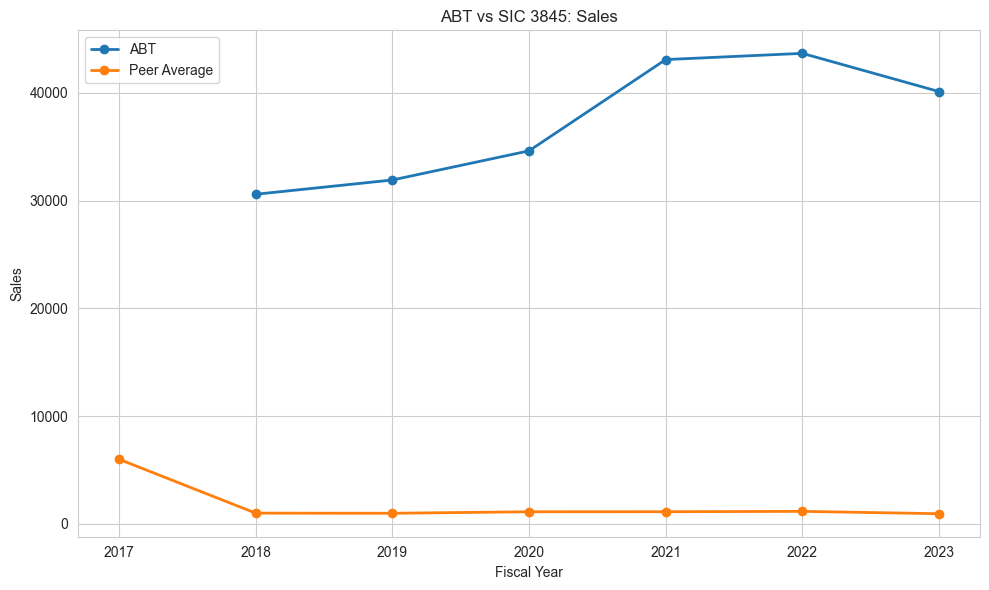

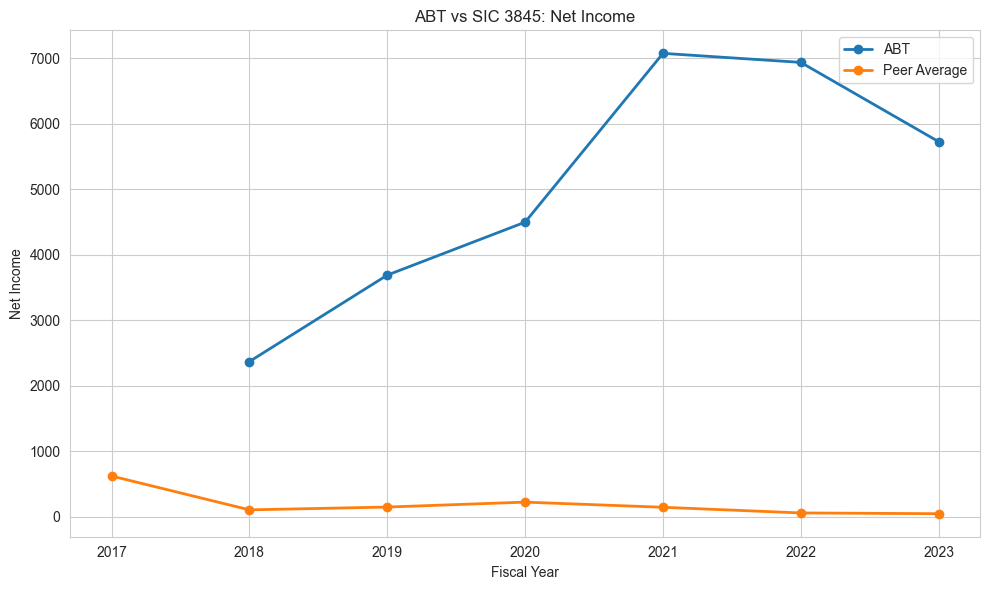

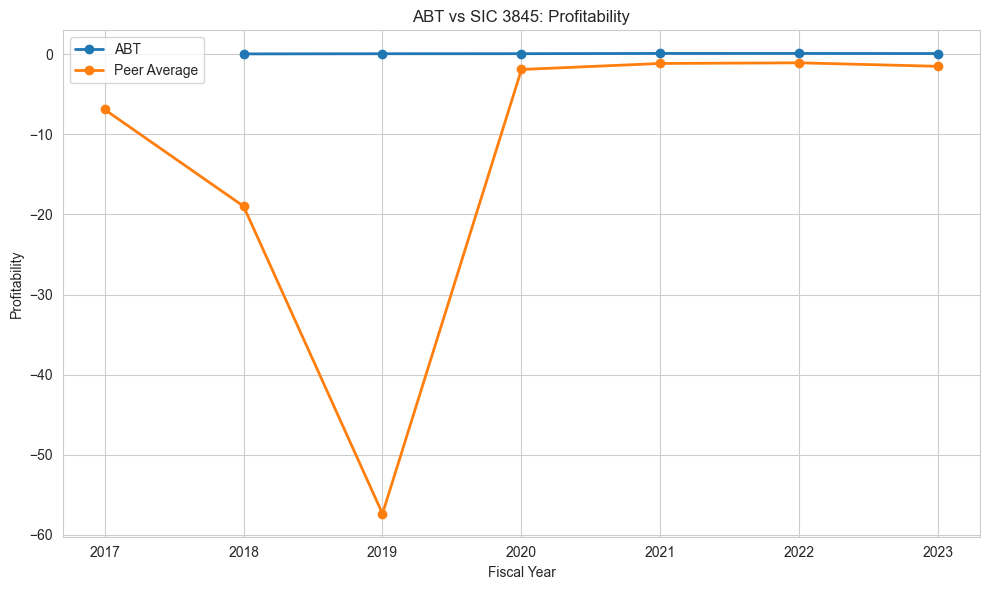

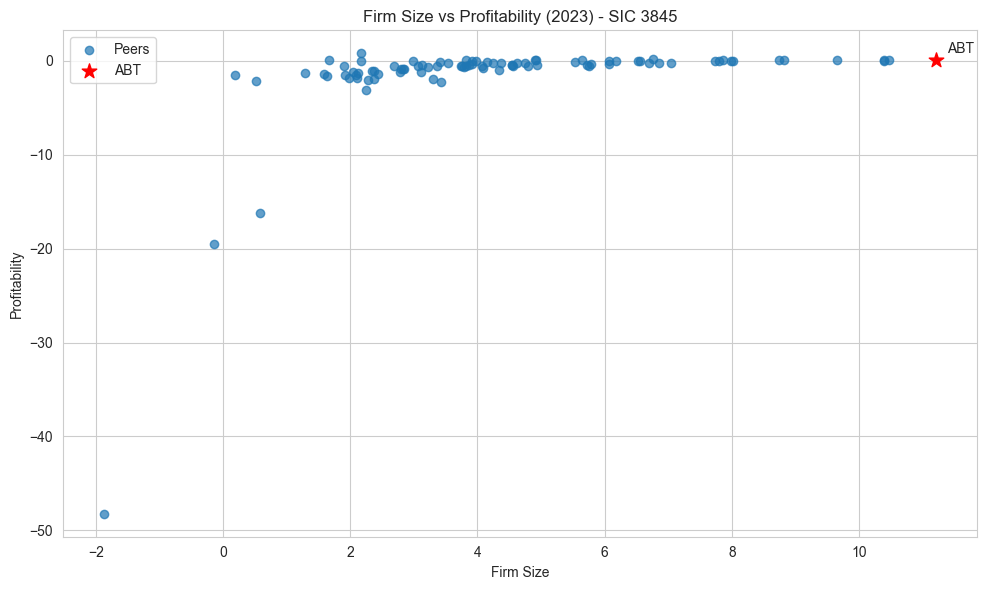


Files saved:
- ABT_vs_peer_comparison.csv
- ABT_same_sic_companies.csv
- ABT_broad_industry_companies.csv


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Copy and clean data
# =========================
data = df.copy()

# Standardize key columns
data['tic'] = data['tic'].astype(str).str.strip().str.upper()
data['conm'] = data['conm'].astype(str).str.strip()
data['sic'] = data['sic'].astype(str).str.strip()
data['fyear'] = pd.to_numeric(data['fyear'], errors='coerce')

# Convert numeric columns
numeric_cols = ['sale', 'ni', 'at', 'firm_size', 'profitability']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop rows with missing year or ticker
data = data.dropna(subset=['tic', 'fyear'])

# =========================
# 2. Find ABT industry info
# =========================
abt_rows = data[data['tic'] == 'ABT']

if abt_rows.empty:
    raise ValueError("ABT is not found in your dataframe.")

abt_sic = abt_rows['sic'].dropna().iloc[0]
abt_prefix2 = abt_sic[:2]

print("ABT SIC:", abt_sic)
print("ABT 2-digit SIC prefix:", abt_prefix2)

# =========================
# 3. Build peer groups
# =========================
same_sic = data[data['sic'] == abt_sic].copy()
broad_industry = data[data['sic'].str.startswith(abt_prefix2, na=False)].copy()

same_sic_companies = same_sic[['tic', 'conm', 'sic']].drop_duplicates()
broad_industry_companies = broad_industry[['tic', 'conm', 'sic']].drop_duplicates()

same_sic_peer_count = same_sic[same_sic['tic'] != 'ABT']['tic'].nunique()
broad_peer_count = broad_industry[broad_industry['tic'] != 'ABT']['tic'].nunique()

print("\n===== Peer Group Summary =====")
print("Same SIC unique companies:", same_sic_companies['tic'].nunique())
print("Same SIC peer companies excluding ABT:", same_sic_peer_count)
print("Broad industry unique companies:", broad_industry_companies['tic'].nunique())
print("Broad industry peer companies excluding ABT:", broad_peer_count)

# =========================
# 4. Choose comparison group
# Rule:
# if same SIC peers >= 5, use same SIC
# otherwise use broad industry (38xx)
# =========================
if same_sic_peer_count >= 5:
    industry_df = same_sic.copy()
    industry_label = f"SIC {abt_sic}"
    print(f"\nUsing strict peer group: {industry_label}")
else:
    industry_df = broad_industry.copy()
    industry_label = f"{abt_prefix2}xx industry"
    print(f"\nUsing broader peer group: {industry_label}")

# Split ABT and peers
abt_df = industry_df[industry_df['tic'] == 'ABT'].copy()
peer_df = industry_df[industry_df['tic'] != 'ABT'].copy()

print("Final peer company count (excluding ABT):", peer_df['tic'].nunique())

# =========================
# 5. Compute yearly peer averages
# =========================
peer_avg = (
    peer_df
    .groupby('fyear')[['sale', 'ni', 'profitability', 'firm_size']]
    .mean()
    .reset_index()
)

abt_yearly = (
    abt_df
    .groupby('fyear')[['sale', 'ni', 'profitability', 'firm_size']]
    .mean()
    .reset_index()
)

# Merge for easier checking
comparison_df = pd.merge(
    abt_yearly,
    peer_avg,
    on='fyear',
    how='outer',
    suffixes=('_ABT', '_PeerAvg')
).sort_values('fyear')

print("\n===== ABT vs Peer Average Table =====")
print(comparison_df)

# =========================
# 6. Plot style
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# =========================
# 7. Figure 1: Sales
# =========================
plt.figure()
plt.plot(abt_yearly['fyear'], abt_yearly['sale'], marker='o', linewidth=2, label='ABT')
plt.plot(peer_avg['fyear'], peer_avg['sale'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Sales')
plt.xlabel('Fiscal Year')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8. Figure 2: Net Income
# =========================
plt.figure()
plt.plot(abt_yearly['fyear'], abt_yearly['ni'], marker='o', linewidth=2, label='ABT')
plt.plot(peer_avg['fyear'], peer_avg['ni'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Net Income')
plt.xlabel('Fiscal Year')
plt.ylabel('Net Income')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9. Figure 3: Profitability
# =========================
plt.figure()
plt.plot(abt_yearly['fyear'], abt_yearly['profitability'], marker='o', linewidth=2, label='ABT')
plt.plot(peer_avg['fyear'], peer_avg['profitability'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Profitability')
plt.xlabel('Fiscal Year')
plt.ylabel('Profitability')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 10. Figure 4: Firm Size vs Profitability
# Use latest available year shared by peers/ABT if possible
# =========================
common_years = sorted(set(industry_df['fyear'].dropna().unique()))

if len(common_years) == 0:
    raise ValueError("No valid fiscal years found in industry_df.")

latest_year = max(common_years)

scatter_df = industry_df[industry_df['fyear'] == latest_year].copy()
scatter_peers = scatter_df[scatter_df['tic'] != 'ABT']
scatter_abt = scatter_df[scatter_df['tic'] == 'ABT']

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_peers['firm_size'],
    scatter_peers['profitability'],
    alpha=0.7,
    label='Peers'
)

if not scatter_abt.empty:
    plt.scatter(
        scatter_abt['firm_size'],
        scatter_abt['profitability'],
        color='red',
        s=120,
        marker='*',
        label='ABT'
    )
    
    # annotate ABT
    for _, row in scatter_abt.iterrows():
        plt.annotate(
            row['tic'],
            (row['firm_size'], row['profitability']),
            textcoords="offset points",
            xytext=(8, 5),
            ha='left'
        )

plt.title(f'Firm Size vs Profitability ({latest_year}) - {industry_label}')
plt.xlabel('Firm Size')
plt.ylabel('Profitability')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 11. Optional: Save outputs
# =========================
comparison_df.to_csv("ABT_vs_peer_comparison.csv", index=False)
same_sic_companies.to_csv("ABT_same_sic_companies.csv", index=False)
broad_industry_companies.to_csv("ABT_broad_industry_companies.csv", index=False)

print("\nFiles saved:")
print("- ABT_vs_peer_comparison.csv")
print("- ABT_same_sic_companies.csv")
print("- ABT_broad_industry_companies.csv")

Using peer group: SIC 3845
Peer companies excluding ABT: 104

===== Improved ABT vs Peer Table =====
   fyear  sale_abt  ni_abt  firm_size_abt  profitability_abt    sale_peer  \
0   2017       NaN     NaN            NaN                NaN  5993.101600   
1   2018   30578.0  2368.0      11.115027           0.035252   995.449395   
2   2019   31904.0  3687.0      11.125600           0.054311   981.263475   
3   2020   34608.0  4495.0      11.192004           0.061959  1122.292409   
4   2021   43075.0  7071.0      11.227853           0.094034  1125.952396   
5   2022   43653.0  6933.0      11.217722           0.093138  1157.980620   
6   2023   40109.0  5723.0      11.201142           0.078168   941.846170   

      ni_peer  firm_size_peer  profitability_peer  
0  620.215800        2.570010            0.024165  
1  104.341921        3.633560           -0.266753  
2  146.885087        3.665956           -0.278289  
3  222.366852        3.879771           -0.246990  
4  143.570560        4

/Users/zhoujinnan/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


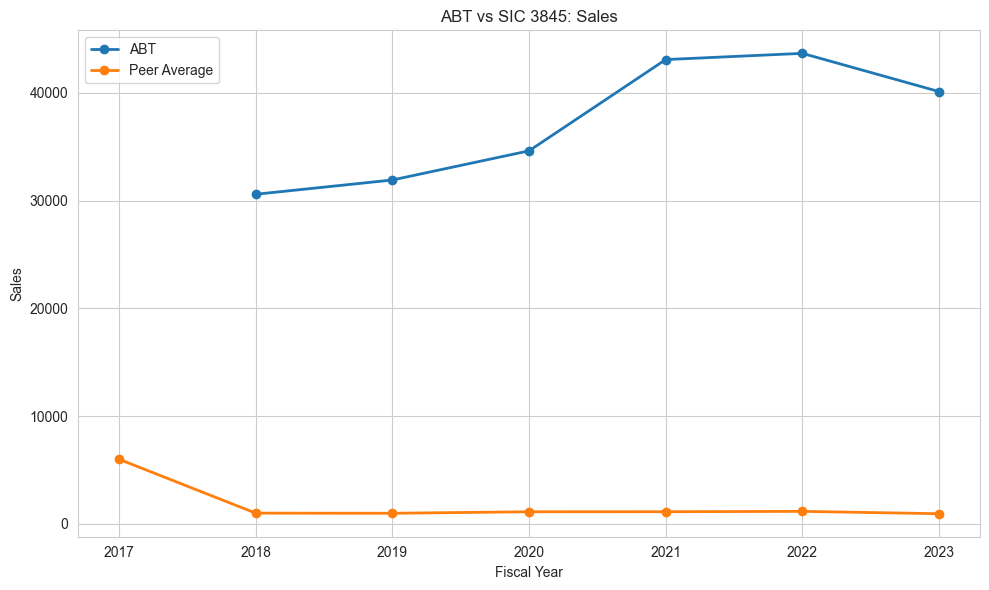

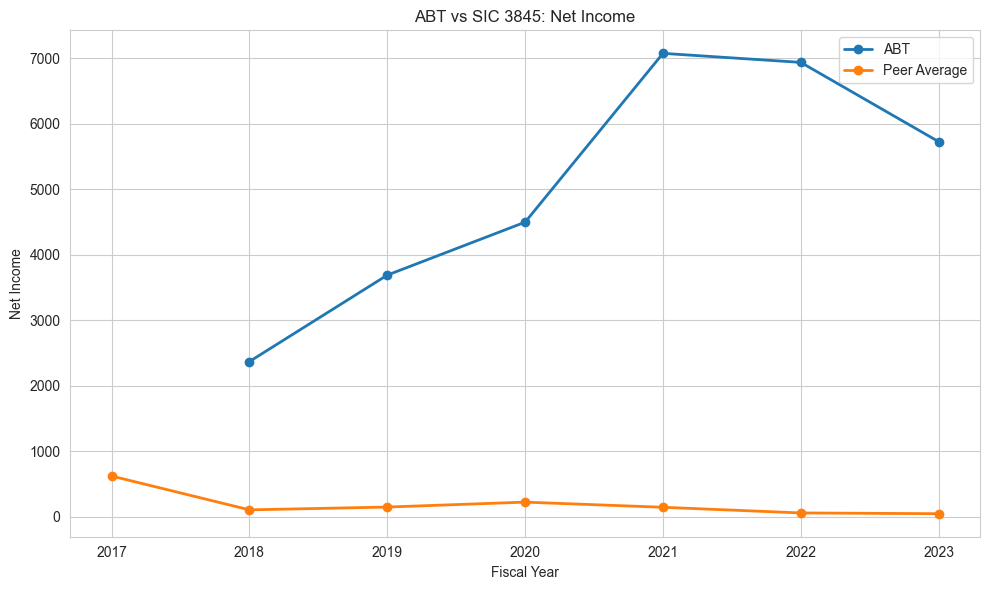

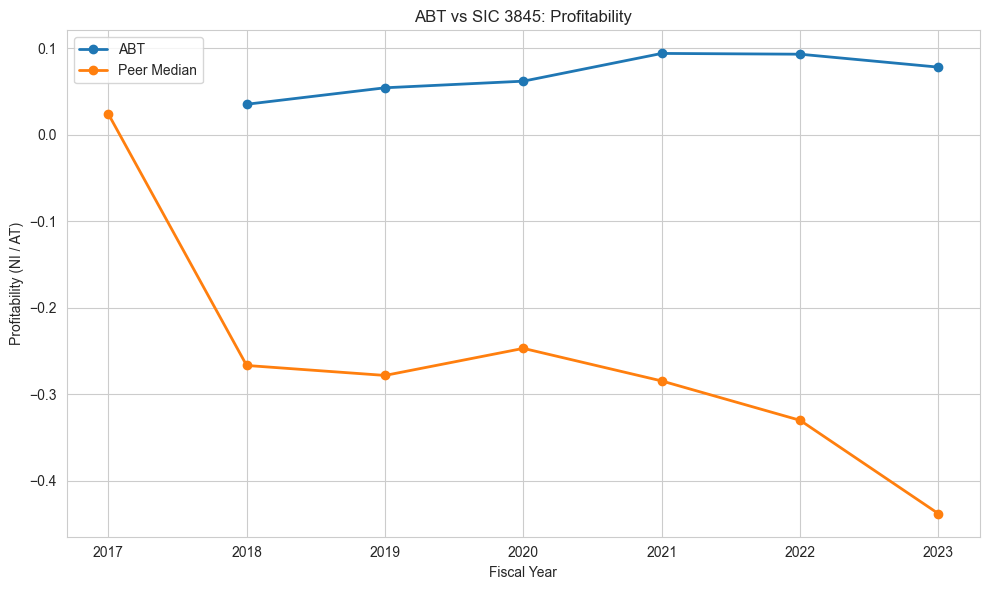

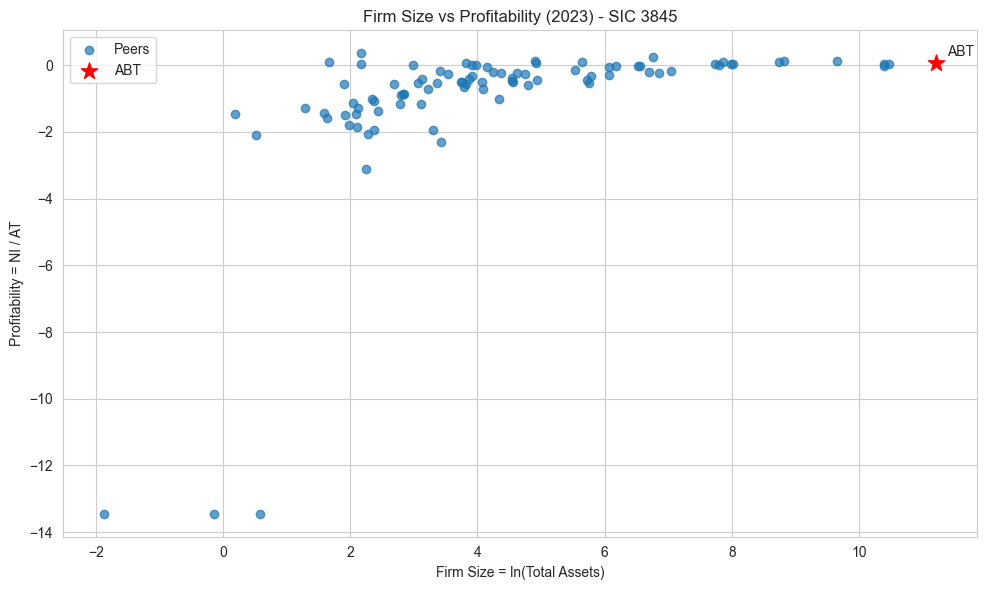


Saved: ABT_vs_SIC3845_improved_comparison.csv


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Copy and clean data
# =========================
data = df.copy()

data['tic'] = data['tic'].astype(str).str.strip().str.upper()
data['conm'] = data['conm'].astype(str).str.strip()
data['sic'] = data['sic'].astype(str).str.strip()
data['fyear'] = pd.to_numeric(data['fyear'], errors='coerce')

for col in ['sale', 'ni', 'at', 'firm_size', 'profitability']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['tic', 'fyear'])

# =========================
# 2. Recalculate firm_size and profitability safely
# =========================
# firm size = ln(total assets), only if at > 0
data['firm_size'] = np.where(data['at'] > 0, np.log(data['at']), np.nan)

# profitability = ni / at, only if at > 0
data['profitability'] = np.where(data['at'] > 0, data['ni'] / data['at'], np.nan)

# =========================
# 3. Winsorize profitability to reduce extreme outliers
# =========================
def winsorize_series(s, lower=0.01, upper=0.99):
    lower_val = s.quantile(lower)
    upper_val = s.quantile(upper)
    return s.clip(lower=lower_val, upper=upper_val)

data['profitability_w'] = data.groupby('fyear')['profitability'].transform(
    lambda x: winsorize_series(x.dropna()) if x.notna().sum() > 0 else x
)

# 如果 transform 后有些行没对齐，可以再保险一点：
mask = data['profitability_w'].isna() & data['profitability'].notna()
data.loc[mask, 'profitability_w'] = data.loc[mask, 'profitability']

# =========================
# 4. Find ABT and choose industry
# =========================
abt_rows = data[data['tic'] == 'ABT']
if abt_rows.empty:
    raise ValueError("ABT is not found in your dataframe.")

abt_sic = abt_rows['sic'].dropna().iloc[0]
abt_prefix2 = abt_sic[:2]

same_sic = data[data['sic'] == abt_sic].copy()
broad_industry = data[data['sic'].str.startswith(abt_prefix2, na=False)].copy()

same_sic_peer_count = same_sic[same_sic['tic'] != 'ABT']['tic'].nunique()

if same_sic_peer_count >= 5:
    industry_df = same_sic.copy()
    industry_label = f"SIC {abt_sic}"
else:
    industry_df = broad_industry.copy()
    industry_label = f"{abt_prefix2}xx industry"

abt_df = industry_df[industry_df['tic'] == 'ABT'].copy()
peer_df = industry_df[industry_df['tic'] != 'ABT'].copy()

print("Using peer group:", industry_label)
print("Peer companies excluding ABT:", peer_df['tic'].nunique())

# =========================
# 5. Compute yearly values
# For peers:
# - sale: mean
# - ni: mean
# - firm_size: mean
# - profitability: median (more robust)
# =========================
peer_yearly = (
    peer_df.groupby('fyear')
    .agg(
        sale_peer=('sale', 'mean'),
        ni_peer=('ni', 'mean'),
        firm_size_peer=('firm_size', 'mean'),
        profitability_peer=('profitability_w', 'median')
    )
    .reset_index()
)

abt_yearly = (
    abt_df.groupby('fyear')
    .agg(
        sale_abt=('sale', 'mean'),
        ni_abt=('ni', 'mean'),
        firm_size_abt=('firm_size', 'mean'),
        profitability_abt=('profitability_w', 'mean')
    )
    .reset_index()
)

comparison_df = pd.merge(abt_yearly, peer_yearly, on='fyear', how='outer').sort_values('fyear')

print("\n===== Improved ABT vs Peer Table =====")
print(comparison_df)

# =========================
# 6. Plot style
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# =========================
# 7. Plot Sales
# =========================
plt.figure()
plt.plot(comparison_df['fyear'], comparison_df['sale_abt'], marker='o', linewidth=2, label='ABT')
plt.plot(comparison_df['fyear'], comparison_df['sale_peer'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Sales')
plt.xlabel('Fiscal Year')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8. Plot Net Income
# =========================
plt.figure()
plt.plot(comparison_df['fyear'], comparison_df['ni_abt'], marker='o', linewidth=2, label='ABT')
plt.plot(comparison_df['fyear'], comparison_df['ni_peer'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Net Income')
plt.xlabel('Fiscal Year')
plt.ylabel('Net Income')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9. Plot Profitability
# =========================
plt.figure()
plt.plot(comparison_df['fyear'], comparison_df['profitability_abt'], marker='o', linewidth=2, label='ABT')
plt.plot(comparison_df['fyear'], comparison_df['profitability_peer'], marker='o', linewidth=2, label='Peer Median')
plt.title(f'ABT vs {industry_label}: Profitability')
plt.xlabel('Fiscal Year')
plt.ylabel('Profitability (NI / AT)')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 10. Scatter plot for latest year
# =========================
latest_year = int(industry_df['fyear'].dropna().max())
scatter_df = industry_df[industry_df['fyear'] == latest_year].copy()

plt.figure(figsize=(10, 6))
peer_scatter = scatter_df[scatter_df['tic'] != 'ABT']
abt_scatter = scatter_df[scatter_df['tic'] == 'ABT']

plt.scatter(
    peer_scatter['firm_size'],
    peer_scatter['profitability_w'],
    alpha=0.7,
    label='Peers'
)

if not abt_scatter.empty:
    plt.scatter(
        abt_scatter['firm_size'],
        abt_scatter['profitability_w'],
        color='red',
        s=150,
        marker='*',
        label='ABT'
    )
    for _, row in abt_scatter.iterrows():
        plt.annotate(
            'ABT',
            (row['firm_size'], row['profitability_w']),
            textcoords='offset points',
            xytext=(8, 5),
            ha='left'
        )

plt.title(f'Firm Size vs Profitability ({latest_year}) - {industry_label}')
plt.xlabel('Firm Size = ln(Total Assets)')
plt.ylabel('Profitability = NI / AT')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 11. Save results
# =========================
comparison_df.to_csv("ABT_vs_SIC3845_improved_comparison.csv", index=False)
print("\nSaved: ABT_vs_SIC3845_improved_comparison.csv")

## 3.1 Peer Group Selection
### Abbott Laboratories (ABT) is compared with firms in the same four-digit SIC industry classification (SIC 3845). This peer group is appropriate because the dataset includes a sufficiently large number of comparable firms, with 104 peer companies excluding ABT. As a result, the analysis adopts a narrow industry definition rather than a broader two-digit SIC classification.
## 3.2 Comparative Performance
### The results show that ABT consistently outperforms the average peer firm in terms of scale and earnings. Its sales are substantially higher than the peer-group average throughout the sample period, indicating that Abbott operates at a much larger scale than most firms in the same industry. A similar pattern is observed for net income, where ABT remains well above the industry average in each year.
## 3.3 Profitability and Market Position
### In terms of profitability, Abbott also performs favorably relative to its peers. Although peer-group profitability may be affected by extreme observations, the overall pattern suggests that ABT maintains a stronger and more stable financial position than the typical firm in SIC 3845. This interpretation is further supported by the firm size–profitability scatter plot, in which Abbott is positioned in the upper-right region, indicating both large size and relatively high profitability.
## 3.4 Conclusion
### Overall, the evidence suggests that Abbott Laboratories is not only one of the largest firms in its industry, but also one of the strongest financial performers within the SIC 3845 peer group.
## Figure Captions
### Figure 1.
#### Sales of ABT versus the average of SIC 3845 peer firms, 2018–2023.
#### The figure shows that Abbott Laboratories reports substantially higher sales than the average peer firm throughout the sample period.
### Figure 2.
#### Net income of ABT versus the average of SIC 3845 peer firms, 2018–2023.
#### Abbott’s net income remains consistently above the industry average, indicating stronger earnings performance relative to peers.
### Figure 3.
#### Profitability of ABT versus SIC 3845 peer firms, 2018–2023.
#### The figure suggests that ABT maintains stronger profitability than the typical peer firm, although peer-group values may be sensitive to outliers.
### Figure 4.
#### Firm size and profitability in SIC 3845, with ABT highlighted, 2023.
#### Abbott is located in the upper-right area of the distribution, indicating both large firm size and relatively high profitability compared with other firms in the same industry.